In [29]:
import geopandas as gpd
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import folium

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
BOUNDARIES_DIR = DATA_DIR / "boundaries" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

In [30]:
TOC_GPKG = BOUNDARIES_DIR / "toc_clean.gpkg"
VILLAGE_GPKG = BOUNDARIES_DIR / "village_clean.gpkg"
TOC_STATS_CSV = OUTPUTS_DIR / "toc_land_value_stats_with_village.csv"
VILLAGE_STATS_CSV = OUTPUTS_DIR / "village_land_value_stats.csv"

In [31]:
toc = gpd.read_file(TOC_GPKG)

# Make sure the index matches index_right used in the CSV
toc = toc.reset_index().rename(columns={"index": "index_right"})
toc = toc.set_index("index_right")

# --- Load stats and merge ---
toc_stats = pd.read_csv(TOC_STATS_CSV)

# Ensure index_right is present
if "index_right" not in toc_stats.columns:
    raise ValueError("index_right not found in TOC stats CSV")

cols_to_use = [c for c in toc_stats.columns if c != "APPLICABIL"]

toc_stats_for_join = toc_stats[cols_to_use].set_index("index_right")

toc_merged = toc.join(
    toc_stats_for_join,
    how="left"
)

toc_merged.head(8)

,OBJECTID,APPLICABIL,geometry,total_taxable_value,total_full_cash,total_land_value,total_acres,parcel_count,taxable_value_per_acre,NAME,intersect_acres
index_right,,,,,,,,,,,
0.0,1,TOD District - Gateway,"POLYGON ((663431.678 894322.427, 663434.469 89...",285984758.0,3.718919e+09,8.830583e+08,2346.119575,3259,121896.923347,Central City,1968.548833
1.0,2,TOD District - Eastlake Garfield,"POLYGON ((654751.939 894390.665, 654764.736 89...",207168885.0,3.014334e+09,8.307006e+08,1015.214786,3323,204064.093422,Central City,1220.462979
2.0,3,TOD District - Midtown,"POLYGON ((654767.886 907514.625, 654767.631 90...",468187974.0,7.310771e+09,1.939664e+09,1053.891243,4552,444246.953429,Encanto,1283.000217
3.0,4,TOD District - Uptown,"POLYGON ((649448.684 915530.44, 654791.762 915...",171863623.0,3.589014e+09,9.414611e+08,1040.744605,3746,165135.252405,Alhambra,918.483468
4.0,5,TOD District - Solano,"POLYGON ((646830.036 919545.608, 646829.436 91...",91072483.0,1.978354e+09,4.115623e+08,848.835227,3414,107291.120997,Alhambra,1100.265433
5.0,6,TOD District - 19North,"POLYGON ((646874.486 919833.609, 646872.259 91...",168607085.0,3.933583e+09,8.894743e+08,1592.456991,5306,105878.580075,Alhambra,1127.773957
6.0,7,50th Street Station Area,"POLYGON ((684257.247 888198.254, 684382.127 88...",74683387.0,1.238704e+09,2.995826e+08,754.371294,270,99000.833669,Camelback East,595.809380
7.0,8,Capitol Extension Area,"POLYGON ((641505.991 895598.434, 643697.045 89...",148353832.0,1.961782e+09,5.294767e+08,807.263067,2396,183773.837815,Central City,1112.954359


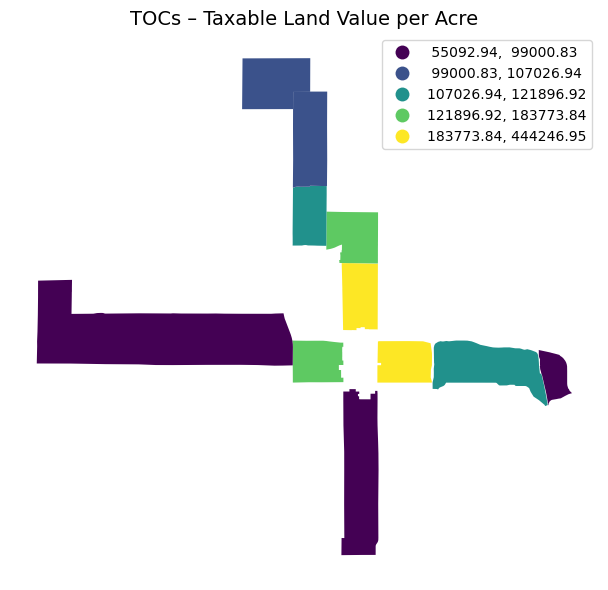

In [32]:
# at last, a map

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

toc_merged.plot(
    column="taxable_value_per_acre",
    ax=ax,
    legend=True,
    cmap="viridis",
    scheme="quantiles",
    k=5,
    edgecolor="none"
)

ax.set_title("TOCs – Taxable Land Value per Acre", fontsize=14)
ax.set_axis_off()

plt.tight_layout()
plt.show()

In [33]:
villages = gpd.read_file(VILLAGE_GPKG)

village_stats = pd.read_csv(VILLAGE_STATS_CSV)

villages_merge = villages.merge(
    village_stats,
    on="NAME",
    how="left"
)

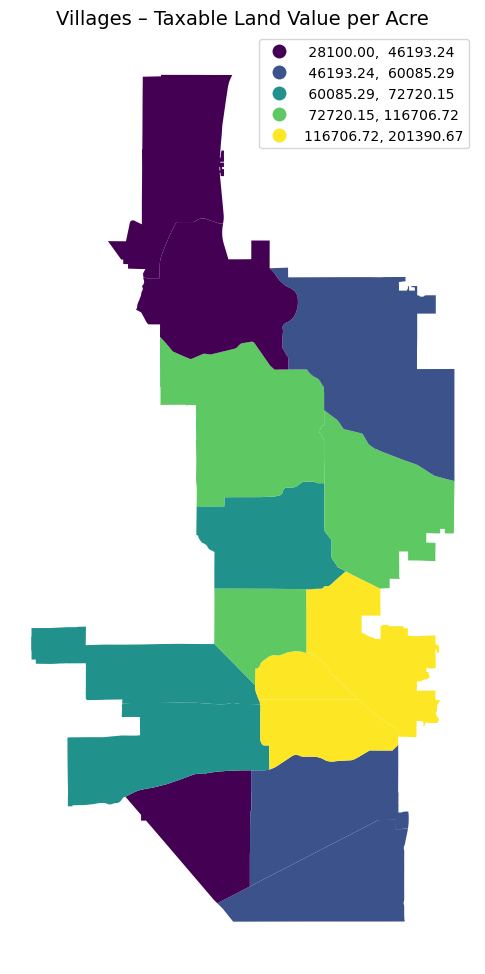

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

villages_merge.plot(
    column="taxable_value_per_acre",
    ax=ax,
    legend=True,
    cmap="viridis",
    scheme="quantiles",
    k=5,
    edgecolor="none"
)

ax.set_title("Villages – Taxable Land Value per Acre", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

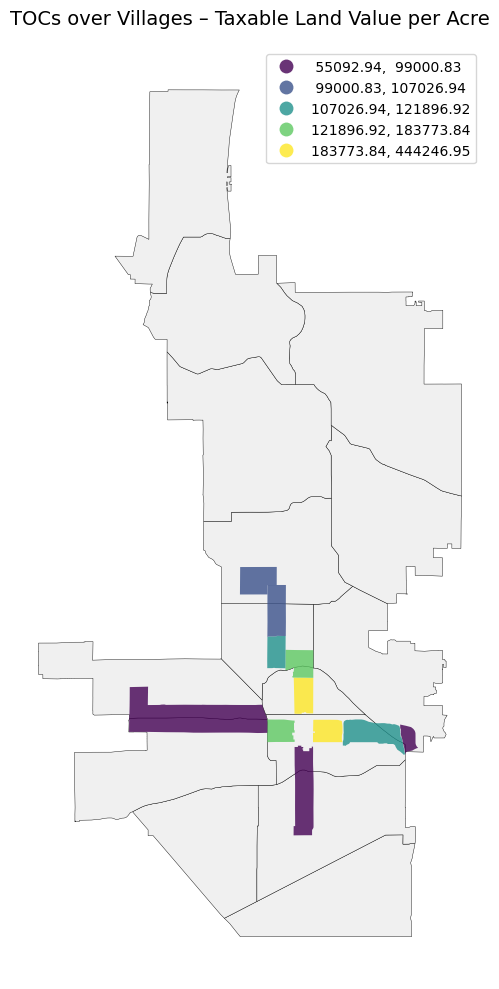

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Base: villages in light grey, no stats
villages.plot(ax=ax, facecolor="#f0f0f0", edgecolor="black", linewidth=0.3)

# Overlay: TOCs by taxable value per acre
toc_merged.plot(
    column="taxable_value_per_acre",
    ax=ax,
    legend=True,
    cmap="viridis",
    scheme="quantiles",
    k=5,
    edgecolor="none",
    alpha=0.8
)

ax.set_title("TOCs over Villages – Taxable Land Value per Acre", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

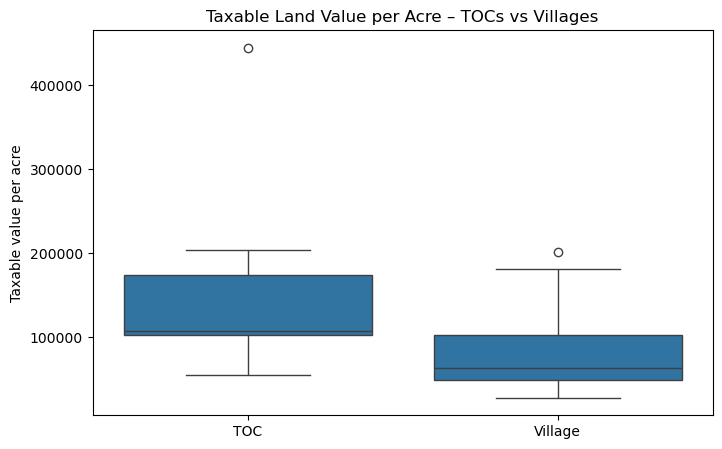

In [36]:
# building a supporting box plot to demonstrate fiscal efficiency

import seaborn as sns

toc_vals = toc_stats[["taxable_value_per_acre"]].assign(level="TOC")
vill_vals = village_stats[["taxable_value_per_acre"]].assign(level="Village")

combo = pd.concat([toc_vals, vill_vals], ignore_index=True)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=combo,
    x="level",
    y="taxable_value_per_acre"
)
plt.title("Taxable Land Value per Acre – TOCs vs Villages")
plt.ylabel("Taxable value per acre")
plt.xlabel("")
plt.show()

In [37]:
# Attach village per-acre value to each TOC
toc_merged = toc_merged.merge(
    villages_merge[["NAME", "taxable_value_per_acre"]]
        .rename(columns={"taxable_value_per_acre": "village_taxable_value_per_acre"}),
    on="NAME",
    how="left"
)

toc_merged["uplift_vs_village"] = (
    toc_merged["taxable_value_per_acre"] - toc_merged["village_taxable_value_per_acre"]
)

In [38]:
import geopandas as gpd

# 1. Reproject to WGS84 for web mapping
vill_web = villages_merge.to_crs(4326).copy()
toc_web  = toc_merged.to_crs(4326).copy()

# 2. Base layer: villages choropleth (light grey)
m = vill_web.explore(
    column="taxable_value_per_acre",
    cmap="grey",               # muted background
    legend=True,
    style_kwds={
        "fillOpacity": 0.3,
        "weight": 0.5,
        "color": "black",      # thin outline
    },
    tooltip=["NAME", "taxable_value_per_acre"],
    name="Villages (value per acre)",
)

# 3. Overlay: TOCs choropleth (bright)
toc_web.explore(
    m=m,                        # add to existing map
    column="taxable_value_per_acre",
    cmap="viridis",             # vivid
    legend=True,               
    style_kwds={
        "fillOpacity": 0.85,
        "weight": 0,           # no border; solid blobs
    },
    tooltip=["APPLICABIL", "NAME", "taxable_value_per_acre",
             "uplift_vs_village"],
    name="TOCs (value per acre)",
)

# 4. Add layer control + save
m.save("tocs_vs_villages_value_per_acre.html")

In [39]:
import numpy as np
import pandas as pd

# Villages: dollar string for tooltips
villages_merge["taxable_value_per_acre_dollar"] = villages_merge["taxable_value_per_acre"].map(
    lambda v: f"${v:,.0f}" if pd.notnull(v) else "N/A"
)

# TOCs: dollar string for tooltips
toc_merged["taxable_value_per_acre_dollar"] = toc_merged["taxable_value_per_acre"].map(
    lambda v: f"${v:,.0f}" if pd.notnull(v) else "N/A"
)

# Percent uplift vs village (TOC is X% higher than its village average)
toc_merged["uplift_pct"] = np.where(
    toc_merged["village_taxable_value_per_acre"].notna()
    & (toc_merged["village_taxable_value_per_acre"] != 0),
    (toc_merged["uplift_vs_village"] / toc_merged["village_taxable_value_per_acre"]) * 100,
    np.nan,
)

toc_merged["village_taxable_value_per_acre_dollar"] = toc_merged["village_taxable_value_per_acre"].map(
    lambda v: f"${v:,.0f}" if pd.notnull(v) else "N/A"
)

# Pretty label for tooltip
toc_merged["uplift_pct_label"] = toc_merged["uplift_pct"].map(
    lambda v: f"{v:,.1f}%" if pd.notnull(v) else "N/A"
)

In [40]:
vill_web = villages_merge.to_crs(4326).copy()
toc_web  = toc_merged.to_crs(4326).copy()

# Base: villages
m = vill_web.explore(
    column="taxable_value_per_acre",   # numeric for coloring
    cmap="grey",
    legend=True,
    style_kwds={
        "fillOpacity": 0.3,
        "weight": 0.5,
        "color": "black",
    },
    tooltip=[
        "NAME",
        "taxable_value_per_acre_dollar",  # formatted $
        "total_acres",
        "parcel_count",
    ],
    name="Villages (value per acre)",
)

# Overlay: TOCs
toc_web.explore(
    m=m,
    column="taxable_value_per_acre",   # numeric for coloring
    cmap="viridis",
    legend=False,
    style_kwds={
        "fillOpacity": 0.85,
        "weight": 0,
    },
    tooltip=[
        "APPLICABIL",
        "NAME",
        "taxable_value_per_acre_dollar",  # formatted $
        "total_acres",
        "uplift_pct_label",               # formatted %
    ],
    name="TOCs (value per acre)",
)

# Optional layer toggle
folium.LayerControl(collapsed=False).add_to(m)

m.save(OUTPUTS_DIR / "tocs_vs_villages_value_per_acre.html")

In [41]:
toc_web = toc_merged.to_crs(4326).copy()

m_uplift = toc_web.explore(
    column="uplift_pct",          # numeric percent for coloring
    cmap="plasma",
    legend=True,
    style_kwds={
        "fillOpacity": 0.85,
        "weight": 0,
    },
    tooltip=[
        "APPLICABIL",
        "NAME",
        "taxable_value_per_acre_dollar",
        "village_taxable_value_per_acre_dollar",     # formatted $
        "uplift_pct_label",                   # "xx.x%"
    ],
    name="TOCs (uplift vs village)",
)

m_uplift
m_uplift.save(OUTPUTS_DIR / "tocs_uplift_vs_villages.html")